# Visualize Result Matrix
Reads the CSVs produced by `generate_result_matrix.ipynb` and renders:
1. **Heatmap tables** — colour-coded per-task primary-metric comparison across models
2. **Grouped bar charts** — primary metric per task, one bar per model
3. **Per-task radar chart** — shape comparison across all metrics

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

pd.set_option('display.max_columns', None)
%matplotlib inline
matplotlib.rcParams.update({'font.size': 12})

In [2]:
RESULTS_DIR = Path(os.path.abspath('')) / 'results' / 'supersubject'

PRIMARY_METRIC = {
    'content_noncontent_task': 'roc_auc',
    'sentence_onset_task': 'roc_auc',
    'iu_boundary_task': 'roc_auc',
    'gpt_surprise_task': 'corr',
    'gpt_surprise_multiclass_task': 'roc_auc_multiclass',
    'pos_task': 'roc_auc_multiclass',
    'word_embedding_decoding_task': 'pairwise_accuracy',
    'whisper_embedding_decoding_task': 'pairwise_accuracy',
    'volume_level_decoding_task': 'corr',
    'llm_decoding_task': 'perplexity_llm',
    'llm_embedding_pretraining_task': 'mse',
}

LOWER_IS_BETTER = {'perplexity_llm', 'mse', 'cross_entropy', 'bce_with_logits', 'cosine_dist', 'nll_embedding'}

TASK_NAME_TO_DIR = {
    'content_noncontent_task': 'content_noncontent',
    'sentence_onset_task': 'sentence_onset',
    'iu_boundary_task': 'iu_boundary',
    'gpt_surprise_task': 'gpt_surprise',
    'gpt_surprise_multiclass_task': 'gpt_surprise_multiclass',
    'pos_task': 'pos',
    'word_embedding_decoding_task': 'word_embedding',
    'whisper_embedding_decoding_task': 'whisper_embedding',
    'volume_level_decoding_task': 'volume_level',
    'llm_decoding_task': 'llm_decoding',
    'llm_embedding_pretraining_task': 'llm_embedding_pretraining',
}

# Short display names for plots
TASK_SHORT = {
    'content_noncontent_task': 'Content',
    'sentence_onset_task': 'Sent Onset',
    'iu_boundary_task': 'IU Boundary',
    'gpt_surprise_task': 'GPT Surprise',
    'gpt_surprise_multiclass_task': 'GPT Surp MC',
    'pos_task': 'POS',
    'word_embedding_decoding_task': 'Word Emb',
    'whisper_embedding_decoding_task': 'Whisper Emb',
    'volume_level_decoding_task': 'Volume',
    'llm_decoding_task': 'LLM Decode',
    'llm_embedding_pretraining_task': 'LLM Emb PT',
}

print(f'Results dir: {RESULTS_DIR}')
print(f'Tasks: {len(PRIMARY_METRIC)}')

Results dir: /pscratch/sd/a/ahhyun/EcoGFound/PODCAST/podcast-benchmark/notebooks/results/supersubject
Tasks: 11


In [3]:
# Load the primary metric matrix (best-lag level)
best_lag_csv = RESULTS_DIR / 'primary_metric_matrix_best_lag.csv'
df_raw = pd.read_csv(best_lag_csv, index_col=0)

# Split into mean and std DataFrames
mean_cols = [c for c in df_raw.columns if c.endswith('_mean')]
std_cols = [c for c in df_raw.columns if c.endswith('_std')]

df_mean = df_raw[mean_cols].copy()
df_mean.columns = [c.replace('_mean', '') for c in df_mean.columns]

df_std = df_raw[std_cols].copy()
df_std.columns = [c.replace('_std', '') for c in df_std.columns]

# Also load fully-averaged
avg_csv = RESULTS_DIR / 'primary_metric_matrix_avg_all_lags_folds.csv'
if avg_csv.exists():
    df_avg_raw = pd.read_csv(avg_csv, index_col=0)
    avg_mean_cols = [c for c in df_avg_raw.columns if c.endswith('_mean')]
    df_avg_mean = df_avg_raw[avg_mean_cols].copy()
    df_avg_mean.columns = [c.replace('_mean', '') for c in df_avg_mean.columns]
else:
    df_avg_mean = None

print(f'Models: {list(df_mean.index)}')
print(f'Tasks with results: {list(df_mean.columns)}')
df_mean

Models: ['baseline', 'brainbert', 'diver', 'popt']
Tasks with results: ['content_noncontent_task', 'gpt_surprise_multiclass_task', 'gpt_surprise_task', 'iu_boundary_task', 'llm_decoding_task', 'llm_embedding_pretraining_task', 'pos_task', 'sentence_onset_task', 'volume_level_decoding_task', 'whisper_embedding_decoding_task', 'word_embedding_decoding_task']


,content_noncontent_task,gpt_surprise_multiclass_task,gpt_surprise_task,iu_boundary_task,llm_decoding_task,llm_embedding_pretraining_task,pos_task,sentence_onset_task,volume_level_decoding_task,whisper_embedding_decoding_task,word_embedding_decoding_task
model,,,,,,,,,,,
baseline,0.590047,0.528724,0.059128,0.501007,NaN,NaN,0.526884,0.880044,0.44758,0.707392,0.511619
brainbert,0.524802,0.485780,0.014867,0.719246,NaN,0.063963,0.494048,0.472617,NaN,0.742866,NaN
diver,0.532903,0.507496,0.056063,0.620536,NaN,0.011346,0.533868,0.603916,NaN,0.732977,NaN
popt,0.526951,0.493359,-0.001806,0.548115,NaN,0.011255,0.540454,0.533724,NaN,0.598898,NaN


## 1. Heatmap Table — Best-Lag Primary Metric

In [4]:
def style_heatmap(df_mean, df_std=None, lower_is_better_set=None):
    """Colour-coded table: green=best, red=worst per column. Shows mean +/- std."""
    if lower_is_better_set is None:
        lower_is_better_set = set()

    # Build display strings (mean +/- std)
    display_df = df_mean.copy()
    for col in display_df.columns:
        for idx in display_df.index:
            m = df_mean.loc[idx, col]
            if pd.isna(m):
                display_df.loc[idx, col] = '—'
            elif df_std is not None and col in df_std.columns:
                s = df_std.loc[idx, col]
                display_df.loc[idx, col] = f'{m:.4f} ± {s:.4f}'
            else:
                display_df.loc[idx, col] = f'{m:.4f}'

    # Rename columns to short names
    display_df.columns = [TASK_SHORT.get(c, c) for c in display_df.columns]

    # Style: colour background by normalized rank per column
    def colour_col(col_name, original_task):
        vals = df_mean[original_task].dropna()
        if len(vals) < 2:
            return [''] * len(df_mean)
        metric = PRIMARY_METRIC.get(original_task, '')
        flip = metric in lower_is_better_set
        vmin, vmax = vals.min(), vals.max()
        styles = []
        for idx in df_mean.index:
            v = df_mean.loc[idx, original_task]
            if pd.isna(v) or vmax == vmin:
                styles.append('background-color: #f0f0f0')
            else:
                norm = (v - vmin) / (vmax - vmin)
                if flip:
                    norm = 1 - norm  # lower is better -> invert
                # green (good) to red (bad)
                r = int(255 * (1 - norm) * 0.8 + 255 * 0.2)
                g = int(255 * norm * 0.8 + 255 * 0.2)
                styles.append(f'background-color: rgb({r},{g},80); color: black')
        return styles

    # Build style DataFrame
    task_list = list(df_mean.columns)
    short_list = [TASK_SHORT.get(t, t) for t in task_list]
    style_df = pd.DataFrame('', index=df_mean.index, columns=short_list)
    for task, short in zip(task_list, short_list):
        style_df[short] = colour_col(short, task)

    return display_df.style.apply(lambda _: style_df, axis=None)

print('Best-Lag Primary Metric (test split)')
style_heatmap(df_mean, df_std, LOWER_IS_BETTER)

Best-Lag Primary Metric (test split)


/tmp/ipykernel_1374171/1354937432.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5900 ± 0.0176' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  display_df.loc[idx, col] = f'{m:.4f} ± {s:.4f}'
/tmp/ipykernel_1374171/1354937432.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5287 ± 0.0220' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  display_df.loc[idx, col] = f'{m:.4f} ± {s:.4f}'
/tmp/ipykernel_1374171/1354937432.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0591 ± 0.0520' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  display_df.loc[idx, col] = f'{m:.4f} ± {s:.4f}'
/tmp/ipykernel_1374171

,Content,GPT Surp MC,GPT Surprise,IU Boundary,LLM Decode,LLM Emb PT,POS,Sent Onset,Volume,Whisper Emb,Word Emb
model,,,,,,,,,,,
baseline,0.5900 ± 0.0176,0.5287 ± 0.0220,0.0591 ± 0.0520,0.5010 ± 0.0236,—,—,0.5269 ± 0.0104,0.8800 ± 0.0435,0.4476 ± 0.0499,0.7074 ± 0.0190,0.5116 ± 0.0037
brainbert,0.5248 ± 0.0215,0.4858 ± 0.0051,0.0149 ± 0.0022,0.7192 ± 0.0248,—,0.0640 ± 0.0029,0.4940 ± 0.0225,0.4726 ± 0.0103,—,0.7429 ± 0.0107,—
diver,0.5329 ± 0.0303,0.5075 ± 0.0085,0.0561 ± 0.0120,0.6205 ± 0.0938,—,0.0113 ± 0.0001,0.5339 ± 0.0401,0.6039 ± 0.0196,—,0.7330 ± 0.0011,—
popt,0.5270 ± 0.0382,0.4934 ± 0.0151,-0.0018 ± 0.0270,0.5481 ± 0.0551,—,0.0113 ± 0.0002,0.5405 ± 0.0014,0.5337 ± 0.0486,—,0.5989 ± 0.0062,—


## 2. Grouped Bar Chart — Primary Metric per Task

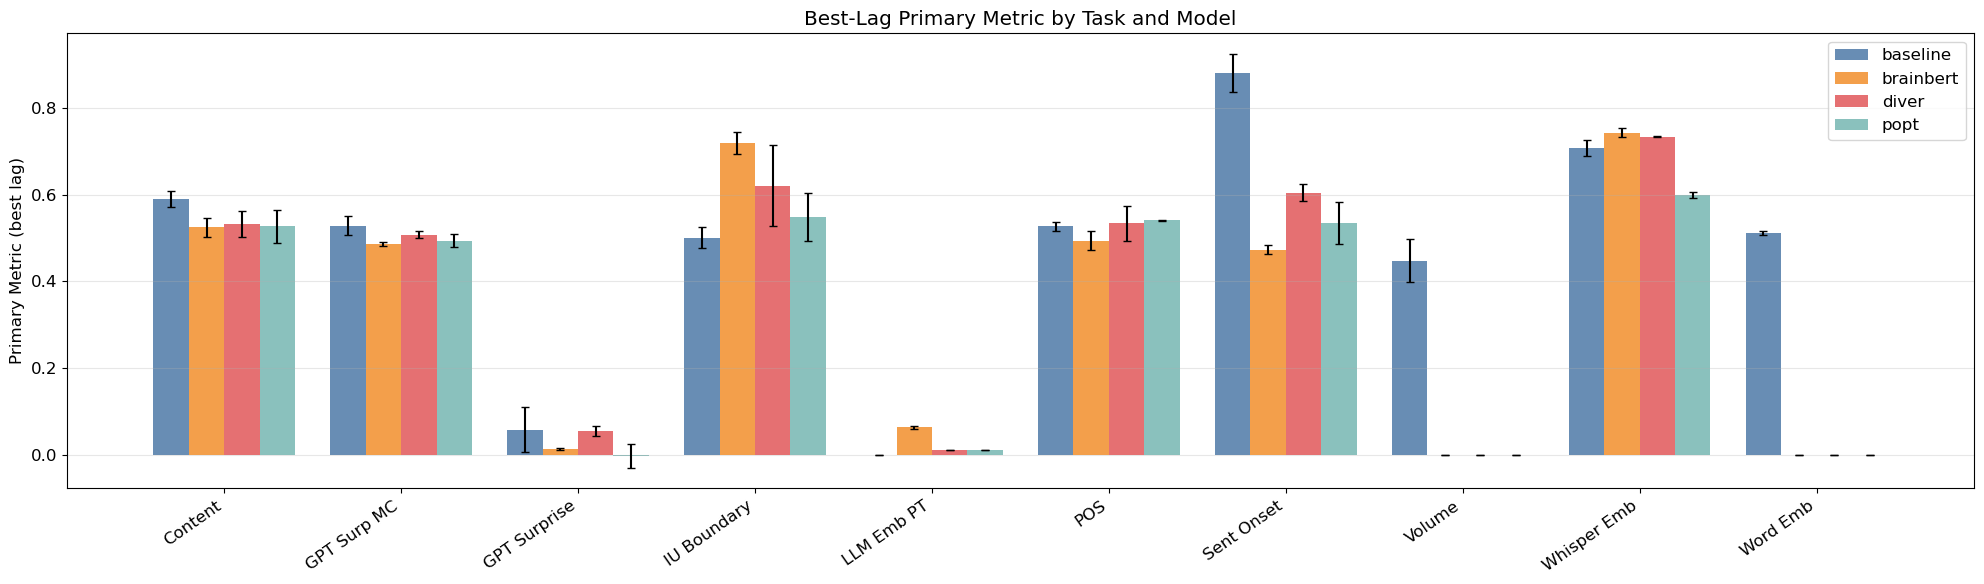

In [5]:
tasks_to_plot = [t for t in df_mean.columns if df_mean[t].notna().sum() > 0]
models = list(df_mean.index)
n_tasks = len(tasks_to_plot)
n_models = len(models)

fig, ax = plt.subplots(figsize=(max(14, n_tasks * 2), 6))

x = np.arange(n_tasks)
width = 0.8 / n_models
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for i, model in enumerate(models):
    vals = [df_mean.loc[model, t] if pd.notna(df_mean.loc[model, t]) else 0 for t in tasks_to_plot]
    errs = [df_std.loc[model, t] if (t in df_std.columns and pd.notna(df_std.loc[model, t])) else 0 for t in tasks_to_plot]
    mask = [pd.notna(df_mean.loc[model, t]) for t in tasks_to_plot]
    # Only plot bars where data exists
    bar_vals = [v if m else 0 for v, m in zip(vals, mask)]
    bar_errs = [e if m else 0 for e, m in zip(errs, mask)]
    bars = ax.bar(x + i * width, bar_vals, width, yerr=bar_errs,
                  label=model, color=colors[i % len(colors)], capsize=3, alpha=0.85)
    # Grey out missing
    for j, m in enumerate(mask):
        if not m:
            bars[j].set_alpha(0.1)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels([TASK_SHORT.get(t, t) for t in tasks_to_plot], rotation=35, ha='right')
ax.set_ylabel('Primary Metric (best lag)')
ax.set_title('Best-Lag Primary Metric by Task and Model')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Per-Task: Metric across Lags (line plot)

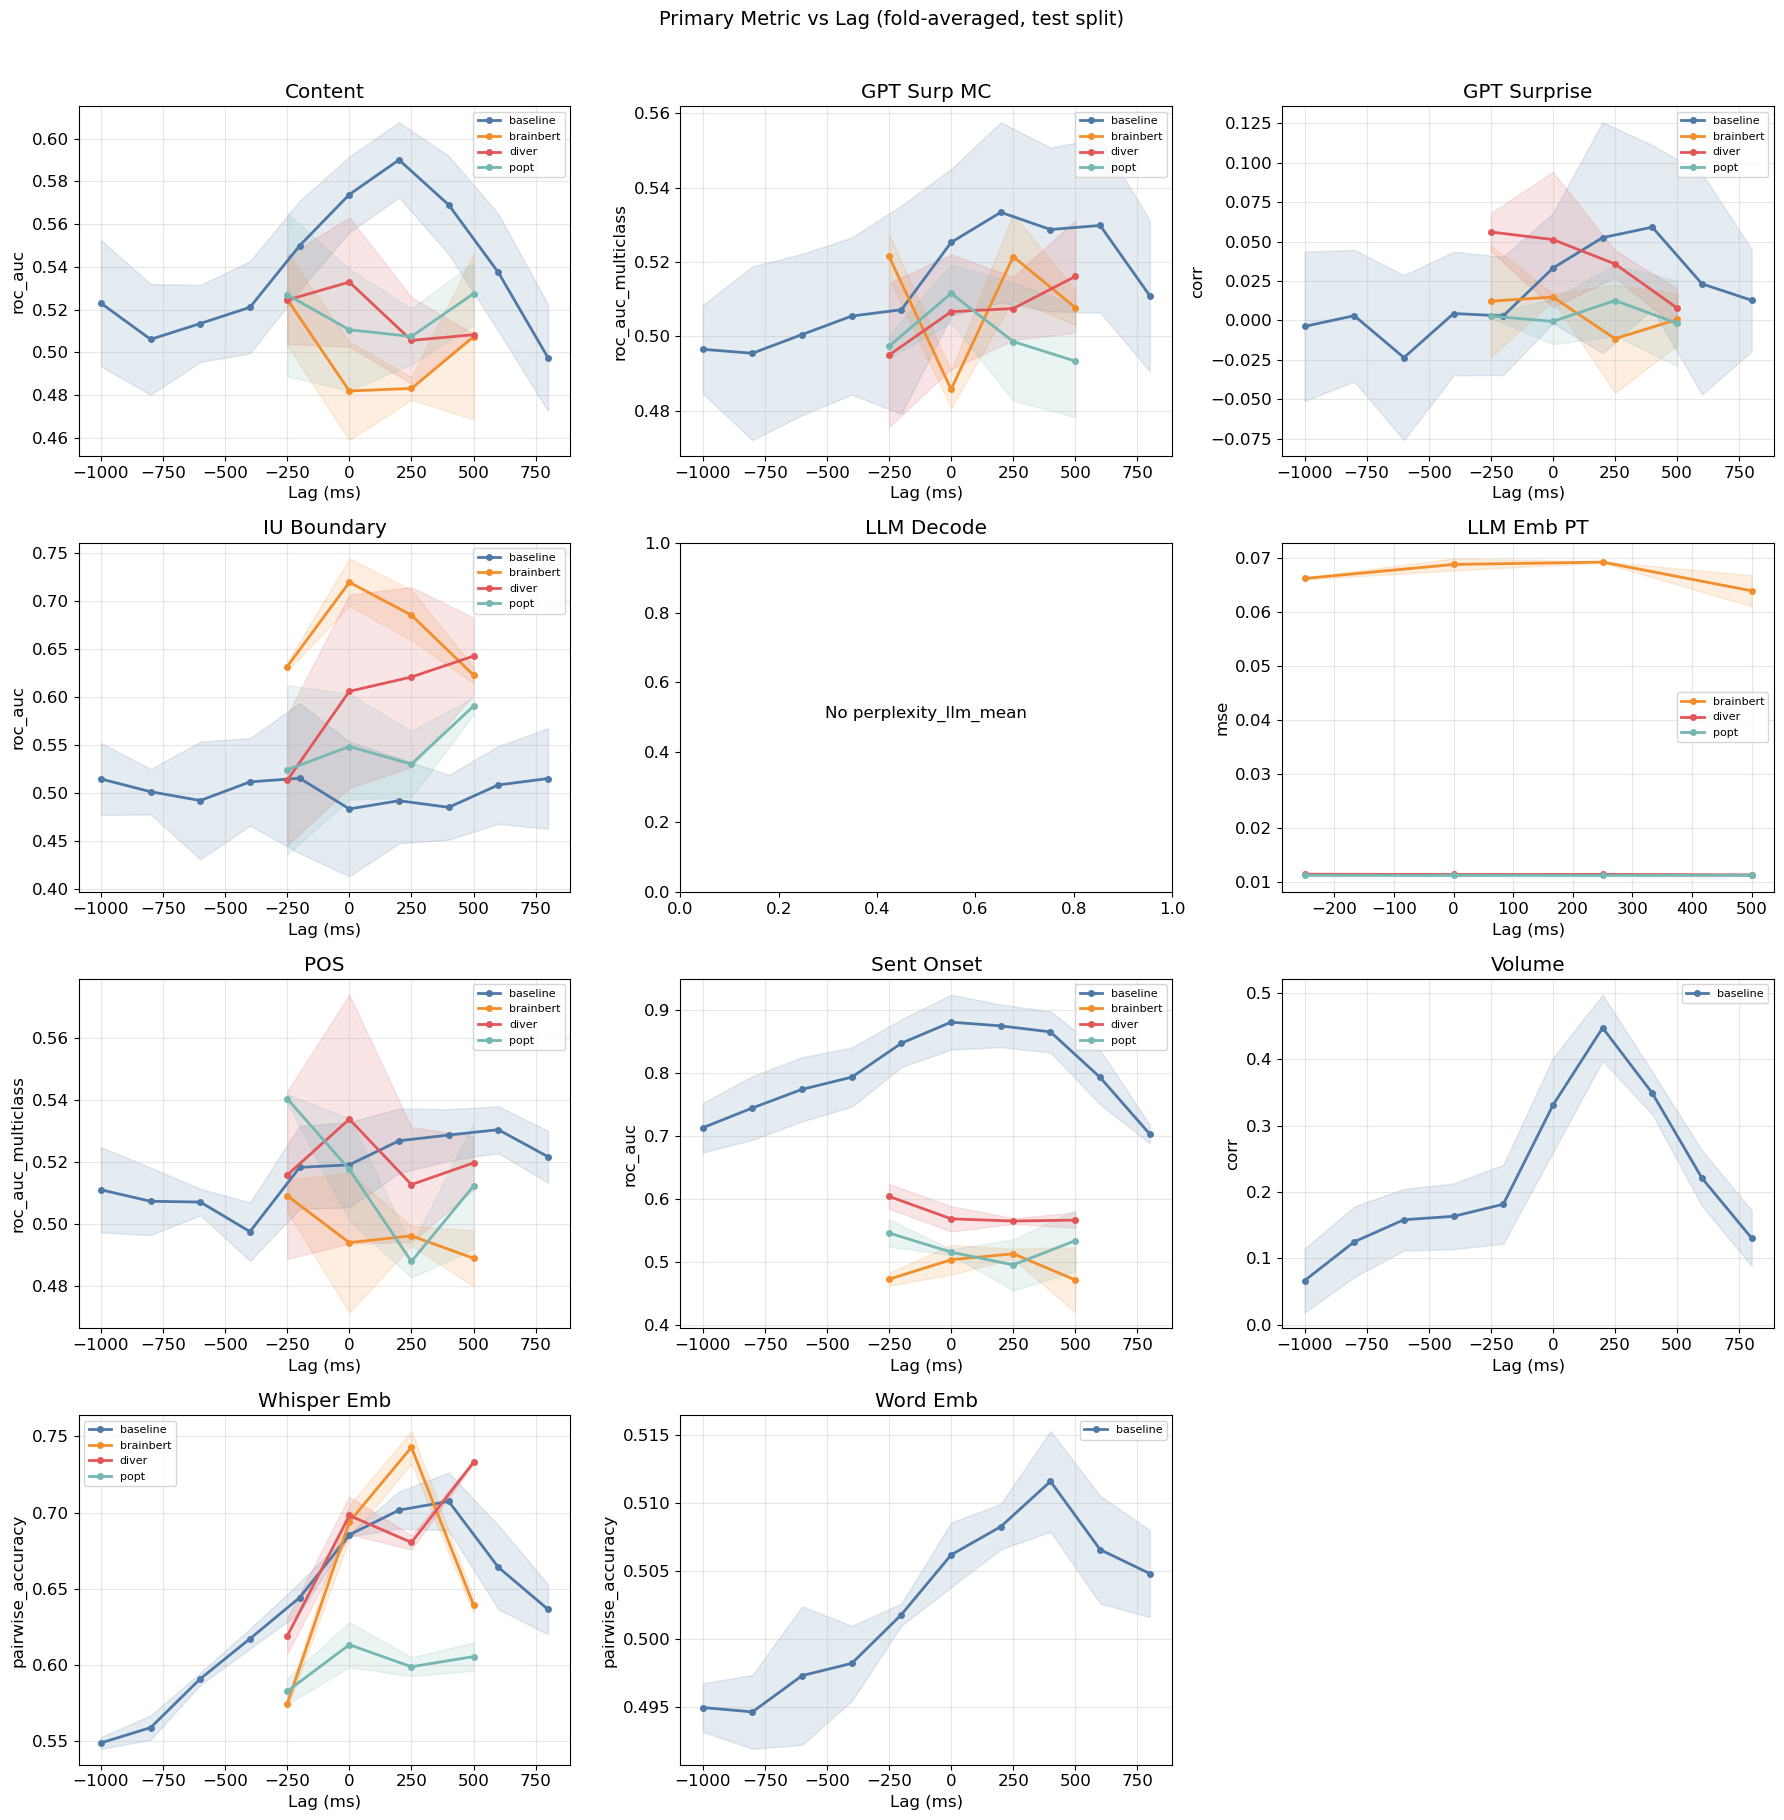

In [6]:
# For each task, plot primary metric vs lag for each model
tasks_with_fold_avg = sorted([
    t for t in PRIMARY_METRIC
    if (RESULTS_DIR / f'{TASK_NAME_TO_DIR[t]}_fold_averaged.csv').exists()
])

n_plots = len(tasks_with_fold_avg)
ncols = 3
nrows = (n_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes = axes.flatten()

colors_line = {'baseline': '#4e79a7', 'brainbert': '#f28e2b', 'diver': '#e15759', 'popt': '#76b7b2'}

for idx, task in enumerate(tasks_with_fold_avg):
    ax = axes[idx]
    task_dir = TASK_NAME_TO_DIR[task]
    csv_path = RESULTS_DIR / f'{task_dir}_fold_averaged.csv'
    df_fold = pd.read_csv(csv_path)

    primary = PRIMARY_METRIC[task]
    mean_col = f'{primary}_mean'
    std_col = f'{primary}_std'

    if mean_col not in df_fold.columns:
        ax.set_title(TASK_SHORT.get(task, task))
        ax.text(0.5, 0.5, f'No {mean_col}', transform=ax.transAxes, ha='center')
        continue

    for model in df_fold['model'].unique():
        mdf = df_fold[df_fold['model'] == model].sort_values('lag')
        ax.plot(mdf['lag'], mdf[mean_col], marker='o', label=model,
                color=colors_line.get(model, None), linewidth=2, markersize=4)
        if std_col in mdf.columns:
            ax.fill_between(mdf['lag'],
                            mdf[mean_col] - mdf[std_col],
                            mdf[mean_col] + mdf[std_col],
                            alpha=0.15, color=colors_line.get(model, None))

    ax.set_title(TASK_SHORT.get(task, task))
    ax.set_xlabel('Lag (ms)')
    ax.set_ylabel(primary)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Primary Metric vs Lag (fold-averaged, test split)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Heatmap Table — Fully Averaged

In [7]:
if df_avg_mean is not None:
    print('Fully Averaged Primary Metric (test split, all lags & folds)')
    style_heatmap(df_avg_mean, lower_is_better_set=LOWER_IS_BETTER)
else:
    print('No fully-averaged matrix found.')

Fully Averaged Primary Metric (test split, all lags & folds)


/tmp/ipykernel_1374171/1354937432.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '—' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  display_df.loc[idx, col] = '—'
/tmp/ipykernel_1374171/1354937432.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '—' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  display_df.loc[idx, col] = '—'
/tmp/ipykernel_1374171/1354937432.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '—' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  display_df.loc[idx, col] = '—'
/tmp/ipykernel_1374171/1354937432.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and wil